# **Day 60: The PyTorch Training Loop - Datasets, DataLoaders and a Reusable Trainer**
*Module 10 - Deep Learning Foundations*

Real deep-learning projects need more than a 5-line loop: data that does not fit in memory, mini-batches, shuffling, validation, checkpoints, early stopping and metrics. Today we build a clean, reusable training pipeline that we will use for the rest of the course (including the remote-sensing projects).

> A training loop repeats: take a batch of data, predict, compute the loss, compute gradients, update the weights. Datasets and DataLoaders feed the batches efficiently; a reusable trainer keeps the loop tidy.
>
> *Example:* Training on 100,000 image patches in batches of 64 means about 1,560 weight updates per pass through the data (one epoch).

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch, torch.nn as nn, copy, time
from torch.utils.data import Dataset, DataLoader, TensorDataset, random_split, WeightedRandomSampler
torch.manual_seed(60); rng = np.random.default_rng(60)
device = "cuda" if torch.cuda.is_available() else "cpu"

## **1. A Custom Dataset**
A `Dataset` needs two methods: `__len__` and `__getitem__(i)` returning one sample. The `DataLoader` batches samples, shuffles them, and can load them in parallel. For remote sensing, `__getitem__` might read one image patch from disk (so the full dataset never needs to fit in memory).

Example: pixel-level land-cover classification from 10 Sentinel-2-like bands (Day 36), stored in a table.

In [2]:
bands = ["B2", "B3", "B4", "B5", "B6", "B7", "B8", "B8A", "B11", "B12"]
mean_spectra = np.array([[0.06, 0.05, 0.03, 0.03, 0.02, 0.02, 0.02, 0.02, 0.01, 0.01],
                         [0.03, 0.05, 0.03, 0.08, 0.22, 0.28, 0.32, 0.33, 0.16, 0.08],
                         [0.05, 0.08, 0.06, 0.12, 0.25, 0.30, 0.34, 0.35, 0.22, 0.13],
                         [0.06, 0.09, 0.08, 0.13, 0.22, 0.26, 0.29, 0.30, 0.25, 0.16],
                         [0.10, 0.11, 0.12, 0.14, 0.16, 0.17, 0.18, 0.19, 0.22, 0.20],
                         [0.11, 0.13, 0.16, 0.18, 0.20, 0.21, 0.22, 0.23, 0.30, 0.26]])
classes = ["water", "forest", "cropland", "grassland", "urban", "bare"]
counts = [400, 1200, 1500, 600, 250, 150]                             # imbalanced, like real maps
X = np.vstack([s * rng.uniform(0.8, 1.2, (c, 1)) + rng.normal(0, 0.015, (c, 10)) for s, c in zip(mean_spectra, counts)]).astype(np.float32)
y = np.concatenate([np.full(c, k) for k, c in enumerate(counts)])

class PixelDataset(Dataset):
    def __init__(self, X, y, mean=None, std=None):
        self.mean = X.mean(0) if mean is None else mean; self.std = X.std(0) if std is None else std
        self.X = torch.tensor((X - self.mean) / self.std, dtype=torch.float32); self.y = torch.tensor(y, dtype=torch.long)
    def __len__(self):
        return len(self.y)
    def __getitem__(self, i):
        return self.X[i], self.y[i]

from sklearn.model_selection import train_test_split
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.2, stratify=y, random_state=0)
X_tr, X_va, y_tr, y_va = train_test_split(X_tr, y_tr, test_size=0.2, stratify=y_tr, random_state=0)
ds_tr = PixelDataset(X_tr, y_tr)
ds_va = PixelDataset(X_va, y_va, ds_tr.mean, ds_tr.std)                # normalise with TRAINING statistics only
ds_te = PixelDataset(X_te, y_te, ds_tr.mean, ds_tr.std)
dl_tr = DataLoader(ds_tr, batch_size=64, shuffle=True, num_workers=0)
dl_va = DataLoader(ds_va, batch_size=256); dl_te = DataLoader(ds_te, batch_size=256)
xb, yb = next(iter(dl_tr)); print("one batch:", xb.shape, yb.shape, "| batches per epoch:", len(dl_tr))

one batch: torch.Size([64, 10]) torch.Size([64]) | batches per epoch: 41


`num_workers > 0` loads batches in parallel processes (important for image files on disk; on Windows/Jupyter keep 0 or put the dataset class in a `.py` module).

## **2. A Reusable Training Function**
- `model.train()` / `model.eval()` switch layers such as dropout and batch normalisation between training and inference behaviour (Day 61).
- Keep the **best** weights by validation loss (checkpointing) and stop when no improvement for `patience` epochs (**early stopping**).

In [3]:
def run_epoch(model, loader, loss_fn, optimizer=None):
    train = optimizer is not None
    model.train(train)
    total_loss, correct, n = 0.0, 0, 0
    with torch.set_grad_enabled(train):
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)
            out = model(xb); loss = loss_fn(out, yb)
            if train:
                optimizer.zero_grad(); loss.backward(); optimizer.step()
            total_loss += loss.item() * len(yb); correct += (out.argmax(1) == yb).sum().item(); n += len(yb)
    return total_loss / n, correct / n

def fit(model, dl_tr, dl_va, loss_fn, optimizer, epochs=100, patience=10, scheduler=None, verbose=True):
    best_loss, best_state, wait, hist = np.inf, None, 0, []
    for ep in range(epochs):
        tr_loss, tr_acc = run_epoch(model, dl_tr, loss_fn, optimizer)
        va_loss, va_acc = run_epoch(model, dl_va, loss_fn)
        if scheduler is not None: scheduler.step()
        hist.append({"epoch": ep, "train_loss": tr_loss, "val_loss": va_loss, "train_acc": tr_acc, "val_acc": va_acc})
        if va_loss < best_loss - 1e-4:
            best_loss, best_state, wait = va_loss, copy.deepcopy(model.state_dict()), 0
        else:
            wait += 1
            if wait >= patience:
                if verbose: print(f"early stopping at epoch {ep}; best val loss {best_loss:.4f}")
                break
    model.load_state_dict(best_state)                                 # restore the best checkpoint
    return pd.DataFrame(hist)

def plot_history(h, title=""):
    fig, axes = plt.subplots(1, 2, figsize=(13, 3.8))
    axes[0].plot(h.train_loss, label="train"); axes[0].plot(h.val_loss, label="validation"); axes[0].set(title=f"{title} loss", xlabel="epoch"); axes[0].legend()
    axes[1].plot(h.train_acc, label="train"); axes[1].plot(h.val_acc, label="validation"); axes[1].set(title=f"{title} accuracy", xlabel="epoch"); axes[1].legend()
    plt.show()

## **3. Training an MLP on Pixels**

early stopping at epoch 79; best val loss 0.0217
trained in 3.2s


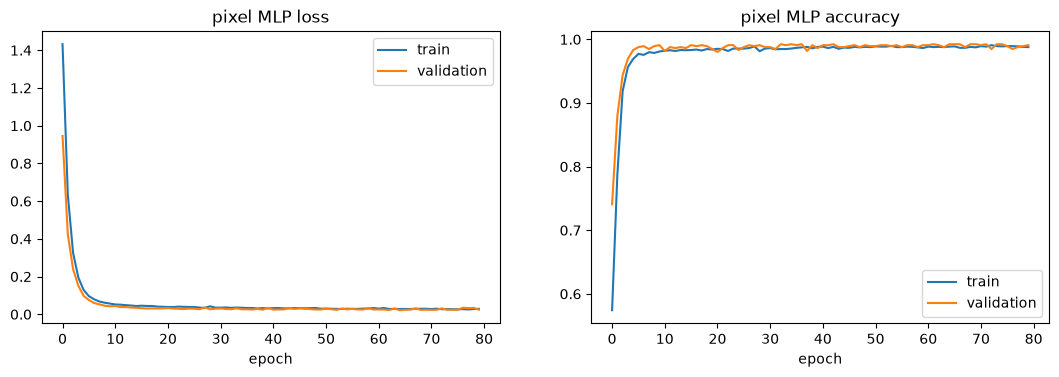

test accuracy 0.980


In [4]:
model = nn.Sequential(nn.Linear(10, 64), nn.ReLU(), nn.Linear(64, 64), nn.ReLU(), nn.Linear(64, 6)).to(device)
opt = torch.optim.Adam(model.parameters(), lr=1e-3)
t0 = time.perf_counter()
hist = fit(model, dl_tr, dl_va, nn.CrossEntropyLoss(), opt, epochs=200, patience=15)
print(f"trained in {time.perf_counter() - t0:.1f}s")
plot_history(hist, "pixel MLP")
te_loss, te_acc = run_epoch(model, dl_te, nn.CrossEntropyLoss())
print(f"test accuracy {te_acc:.3f}")

In [5]:
from sklearn.metrics import classification_report
with torch.no_grad():
    pred = model(ds_te.X.to(device)).argmax(1).cpu().numpy()
print(classification_report(y_te, pred, target_names=classes, digits=3))

              precision    recall  f1-score   support

       water      1.000     1.000     1.000        80
      forest      0.996     0.996     0.996       240
    cropland      0.997     0.993     0.995       300
   grassland      0.992     1.000     0.996       120
       urban      0.849     0.900     0.874        50
        bare      0.815     0.733     0.772        30

    accuracy                          0.980       820
   macro avg      0.941     0.937     0.939       820
weighted avg      0.980     0.980     0.980       820



## **4. Class Imbalance: Weighted Loss or Weighted Sampler**
- **Weighted loss**: `nn.CrossEntropyLoss(weight=w)` with $w_k \propto 1/n_k$.
- **WeightedRandomSampler**: oversample rare classes in each mini-batch.

In [6]:
from sklearn.metrics import f1_score
w = torch.tensor(len(y_tr) / (6 * np.bincount(y_tr)), dtype=torch.float32).to(device)
results = {}
for name, (loss_fn, loader) in {"plain": (nn.CrossEntropyLoss(), dl_tr),
                                "weighted loss": (nn.CrossEntropyLoss(weight=w), dl_tr),
                                "weighted sampler": (nn.CrossEntropyLoss(), DataLoader(ds_tr, batch_size=64, sampler=WeightedRandomSampler(
                                    weights=(1 / np.bincount(y_tr))[y_tr], num_samples=len(y_tr), replacement=True)))}.items():
    torch.manual_seed(0)
    m = nn.Sequential(nn.Linear(10, 64), nn.ReLU(), nn.Linear(64, 64), nn.ReLU(), nn.Linear(64, 6)).to(device)
    fit(m, loader, dl_va, loss_fn, torch.optim.Adam(m.parameters(), lr=1e-3), epochs=200, patience=15, verbose=False)
    with torch.no_grad(): p_ = m(ds_te.X.to(device)).argmax(1).cpu().numpy()
    results[name] = {"accuracy": np.mean(p_ == y_te), "macro F1": f1_score(y_te, p_, average="macro"), "F1 bare (rarest)": f1_score(y_te, p_, average=None)[5]}
pd.DataFrame(results).T.round(3)

,accuracy,macro F1,F1 bare (rarest)
plain,0.978,0.930,0.737
weighted loss,0.982,0.946,0.807
weighted sampler,0.982,0.945,0.800


## **5. Images Through the Same Pipeline: Digits**
An MLP treats an 8x8 image as a flat vector of 64 numbers (it ignores spatial structure; CNNs fix that on Day 62).

In [7]:
from sklearn.datasets import load_digits
Xd, yd = load_digits(return_X_y=True)
Xd = torch.tensor(Xd / 16.0, dtype=torch.float32); yd = torch.tensor(yd)
full = TensorDataset(Xd, yd)
g = torch.Generator().manual_seed(0)
tr_d, va_d, te_d = random_split(full, [1200, 297, 300], generator=g)
mlp = nn.Sequential(nn.Linear(64, 128), nn.ReLU(), nn.Linear(128, 10))
h_d = fit(mlp, DataLoader(tr_d, 32, shuffle=True), DataLoader(va_d, 256), nn.CrossEntropyLoss(), torch.optim.Adam(mlp.parameters(), 1e-3), epochs=100, patience=10)
print("digits test accuracy:", round(run_epoch(mlp, DataLoader(te_d, 256), nn.CrossEntropyLoss())[1], 3))

early stopping at epoch 84; best val loss 0.0844
digits test accuracy: 0.963


# **Part 2: Going Deeper - Saving, Loading and Reproducibility**

Save the **state_dict** (weights) plus everything needed to use the model: the architecture definition, normalisation statistics and class names. Loading = rebuild the architecture, then load the weights.

In [8]:
ckpt = {"state_dict": model.state_dict(), "mean": ds_tr.mean, "std": ds_tr.std, "classes": classes, "bands": bands,
        "arch": {"n_in": 10, "hidden": 64, "n_out": 6}}
torch.save(ckpt, "pixel_mlp.pt")
loaded = torch.load("pixel_mlp.pt", weights_only=False)
m2 = nn.Sequential(nn.Linear(10, 64), nn.ReLU(), nn.Linear(64, 64), nn.ReLU(), nn.Linear(64, 6))
m2.load_state_dict(loaded["state_dict"]); m2.eval()
new_pixel = np.array([[0.04, 0.06, 0.04, 0.09, 0.23, 0.29, 0.33, 0.34, 0.17, 0.08]], dtype=np.float32)
with torch.no_grad():
    prob = torch.softmax(m2(torch.tensor((new_pixel - loaded["mean"]) / loaded["std"])), 1).numpy()[0]
print("predicted:", loaded["classes"][prob.argmax()], "| probabilities:", dict(zip(loaded["classes"], prob.round(3).tolist())))

predicted: forest | probabilities: {'water': 0.0, 'forest': 1.0, 'cropland': 0.0, 'grassland': 0.0, 'urban': 0.0, 'bare': 0.0}


### Reproducibility in PyTorch
```python
torch.manual_seed(0); np.random.seed(0); random.seed(0)
torch.use_deterministic_algorithms(True)          # error if a non-deterministic op is used
torch.backends.cudnn.benchmark = False
DataLoader(..., generator=torch.Generator().manual_seed(0), worker_init_fn=seed_worker)
```
Even then, results can differ across hardware and library versions: report mean +/- sd over several seeds (Day 2).

## **Practice Problems**
1. Train the pixel MLP with batch sizes 8, 64 and 512 (same epochs). Compare speed and validation accuracy.
2. Add a learning-rate scheduler (`torch.optim.lr_scheduler.StepLR(opt, 30, 0.1)`) and compare the loss curves.
3. Run the pixel model with 5 different seeds and report test accuracy as mean +/- sd.
4. *(Advanced)* Write a `Dataset` that generates samples **on the fly** (e.g. adds random illumination scaling to each spectrum every time it is accessed). This is data augmentation (Day 64).

batch   8:   9.6s | best val acc 0.992


batch  64:   1.9s | best val acc 0.994


batch 512:   0.8s | best val acc 0.989


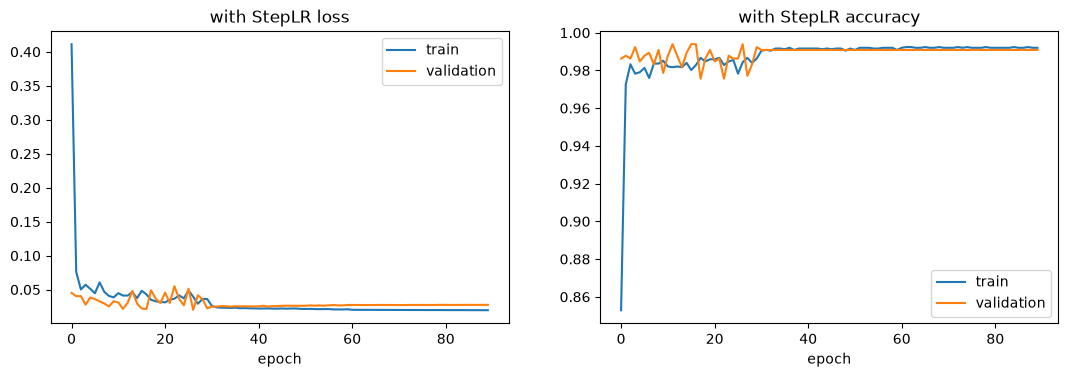

test accuracy over 5 seeds: 0.981 +/- 0.001
same index, two different augmented samples: tensor([0.5381, 0.8045, 0.3688]) tensor([0.7446, 1.0841, 0.5332])


In [9]:
# Solution 1
for bs in [8, 64, 512]:
    torch.manual_seed(0); m = nn.Sequential(nn.Linear(10, 64), nn.ReLU(), nn.Linear(64, 64), nn.ReLU(), nn.Linear(64, 6))
    t0 = time.perf_counter(); hh = fit(m, DataLoader(ds_tr, bs, shuffle=True), dl_va, nn.CrossEntropyLoss(), torch.optim.Adam(m.parameters(), 1e-3), epochs=40, patience=100, verbose=False)
    print(f"batch {bs:>3}: {time.perf_counter() - t0:5.1f}s | best val acc {hh.val_acc.max():.3f}")
# Solution 2
torch.manual_seed(0); m = nn.Sequential(nn.Linear(10, 64), nn.ReLU(), nn.Linear(64, 64), nn.ReLU(), nn.Linear(64, 6)); o = torch.optim.Adam(m.parameters(), 1e-2)
hs = fit(m, dl_tr, dl_va, nn.CrossEntropyLoss(), o, epochs=90, patience=100, scheduler=torch.optim.lr_scheduler.StepLR(o, 30, 0.1), verbose=False)
plot_history(hs, "with StepLR")
# Solution 3
accs = []
for seed in range(5):
    torch.manual_seed(seed); m = nn.Sequential(nn.Linear(10, 64), nn.ReLU(), nn.Linear(64, 64), nn.ReLU(), nn.Linear(64, 6))
    fit(m, DataLoader(ds_tr, 64, shuffle=True, generator=torch.Generator().manual_seed(seed)), dl_va, nn.CrossEntropyLoss(), torch.optim.Adam(m.parameters(), 1e-3), epochs=200, patience=15, verbose=False)
    accs.append(run_epoch(m, dl_te, nn.CrossEntropyLoss())[1])
print(f"test accuracy over 5 seeds: {np.mean(accs):.3f} +/- {np.std(accs):.3f}")
# Solution 4
class AugmentedPixels(PixelDataset):
    def __getitem__(self, i):
        x_raw = self.X[i] * torch.tensor(self.std) + torch.tensor(self.mean)            # back to reflectance
        x_aug = x_raw * torch.empty(1).uniform_(0.85, 1.15)                              # random illumination
        return (x_aug - torch.tensor(self.mean)) / torch.tensor(self.std), self.y[i]
aug_ds = AugmentedPixels(X_tr, y_tr)
print("same index, two different augmented samples:", aug_ds[0][0][:3], aug_ds[0][0][:3])

## **Key References**
- Paszke, A. et al. (2019). PyTorch: An imperative style, high-performance deep learning library. *NeurIPS 32*.
- Prechelt, L. (1998). Early stopping - but when? In *Neural Networks: Tricks of the Trade*, LNCS 1524, 55-69.
- Goodfellow, I., Bengio, Y., & Courville, A. (2016). *Deep Learning*, Chapter 7.8 (early stopping). MIT Press.
- Stewart, A. J., Robinson, C., Corley, I. A., Ortiz, A., Lavista Ferres, J. M., & Banerjee, A. (2022). TorchGeo: Deep learning with geospatial data. *SIGSPATIAL 2022*.